# POF 2017-2018 — Escolaridade e Endividamento Familiar

**TCC — Universidade de São Paulo**

Este notebook lê os arquivos brutos da POF, constrói as variáveis analíticas e roda os modelos econométricos.

### Estrutura
1. Configuração de caminhos e mapeamento de arquivos
2. Funções de leitura dos arquivos TXT em formato posicional
3. Carregamento de todos os arquivos POF
4. Definição dos códigos de dívida
5. Agregação por UC e construção das variáveis analíticas
6. Validação das dívidas agregadas
7. Análise descritiva
8. Modelos de regressão (abordagem em duas partes + OLS log-linear)
9. Diagnósticos do modelo


## 1. Configuração

In [1]:
import pandas as pd
import polars as pl
import os

base_path = r"C:\Users\Joao Pedro\Desktop\repositorios\tcc-giovanna"
pasta_txt = os.path.join(base_path, "Dados_20230713")
caminho_excel = os.path.join(base_path, "Dicionários de váriaveis.xlsx")

# Mapeamento dos arquivos TXT para os seus respectivos Dicionários (abas do Excel)
arquivos_pof = {
    "DOMICILIO.TXT": "Domicílio",
    "MORADOR.TXT": "Morador",
    "MORADOR_QUALI_VIDA.TXT": "Morador - Qualidade de Vida",
    "ALUGUEL_ESTIMADO.TXT": "Aluguel Estimado",
    "DESPESA_COLETIVA.TXT": "Despesa Coletiva",
    "CADERNETA_COLETIVA.TXT": "Caderneta Coletiva",
    "DESPESA_INDIVIDUAL.TXT": "Despesa Individual",
    "RENDIMENTO_TRABALHO.TXT": "Rendimento do Trabalho",
    "OUTROS_RENDIMENTOS.TXT": "Outros Rendimentos",
    "CONSUMO_ALIMENTAR.TXT": "Consumo Alimentar",
    "SERVICO_NAO_MONETARIO_POF2.TXT": "Serviços Não Monetários - POF 2",
    "SERVICO_NAO_MONETARIO_POF4.TXT": "Serviços Não Monetários - POF 4",
    "CARACTERISTICAS_DIETA.TXT": "Características da Dieta",
    "CONDICOES_VIDA.TXT": "Condições de Vida",
    "INVENTARIO.TXT": "Inventário",
    "RESTRICAO_PRODUTOS_SERVICOS_SAUDE.TXT": "Restrição - Saúde"
}

## 2. Funções de leitura

In [2]:
def extrair_layout_do_dicionario_excel(caminho_excel, aba):
    """
    Lê a aba do dicionário Excel e retorna uma lista de tuplas
    (nome_variável, posição_inicial_0indexed, tamanho, divisor_decimal).
    """
    df_dic = pd.read_excel(caminho_excel, sheet_name=aba, dtype=str)

    # Localiza a linha que contém o cabeçalho real da tabela
    try:
        header_idx = df_dic[df_dic.apply(
            lambda r: r.astype(str).str.contains('Posição Inicial', na=False).any(),
            axis=1
        )].index[0]

        df_dic.columns = df_dic.iloc[header_idx]
        df_dic = df_dic.iloc[header_idx + 1:].copy()
    except IndexError:
        print(f"⚠️ Erro ao encontrar cabeçalho na aba: {aba}")
        return []

    df_dic = df_dic.dropna(subset=['Posição Inicial', 'Código da variável'])
    df_dic = df_dic[df_dic['Posição Inicial'].astype(str).str.isnumeric()]

    layout = []
    for _, row in df_dic.iterrows():
        nome = str(row['Código da variável']).strip()
        pos = int(row['Posição Inicial']) - 1  # converte para índice 0-based
        tamanho = int(row['Tamanho'])

        decimais = row.get('Decimais', None)
        div = 1
        if pd.notna(decimais) and str(decimais).strip().isnumeric():
            div = 10 ** int(float(str(decimais).strip()))

        layout.append((nome, pos, tamanho, div))

    return layout


def ler_pof_txt_com_polars(caminho_txt, layout):
    """
    Lê arquivo TXT de largura fixa da POF usando Polars.
    Cada linha é lida como uma única string 'raw', depois fatiada
    conforme o layout extraído do dicionário.
    """
    print(f"Lendo o arquivo: {caminho_txt}...")

    df = pl.read_csv(
        caminho_txt,
        has_header=False,
        new_columns=["raw"],
        truncate_ragged_lines=True,
        quote_char=None
    )

    expressoes = []
    for nome, start, length, div_decimal in layout:
        col_expr = pl.col("raw").str.slice(start, length).str.strip_chars()
        col_expr = pl.when(col_expr == "").then(None).otherwise(col_expr)

        if div_decimal > 1:
            # Variável numérica com casas decimais implícitas (ex.: valores monetários)
            col_expr = (col_expr.cast(pl.Float64, strict=False) / div_decimal).alias(nome)
        else:
            col_expr = col_expr.alias(nome)

        expressoes.append(col_expr)

    df_estruturado = df.select(expressoes)
    return df_estruturado

## 3. Carregamento de todos os arquivos POF

In [3]:
dataframes_pof = {}

for arquivo_txt, aba_excel in arquivos_pof.items():

    caminho_txt = os.path.join(pasta_txt, arquivo_txt)

    if os.path.exists(caminho_txt):
        layout_atual = extrair_layout_do_dicionario_excel(caminho_excel, aba_excel)

        if not layout_atual:
            continue

        df_polars = ler_pof_txt_com_polars(caminho_txt, layout_atual)

        nome_chave = arquivo_txt.split(".")[0]
        dataframes_pof[nome_chave] = df_polars

        print(f"[{nome_chave}] OK -> {df_polars.shape}")

        df_polars.write_parquet(os.path.join(base_path, f"DadosParquet\\{nome_chave}.parquet"))

    else:
        print(f"⚠️ TXT não encontrado: {caminho_txt}")

Lendo o arquivo: C:\Users\Joao Pedro\Desktop\repositorios\tcc-giovanna\Dados_20230713\DOMICILIO.TXT...
[DOMICILIO] OK -> (57920, 38)
Lendo o arquivo: C:\Users\Joao Pedro\Desktop\repositorios\tcc-giovanna\Dados_20230713\MORADOR.TXT...
[MORADOR] OK -> (178431, 56)
Lendo o arquivo: C:\Users\Joao Pedro\Desktop\repositorios\tcc-giovanna\Dados_20230713\MORADOR_QUALI_VIDA.TXT...
[MORADOR_QUALI_VIDA] OK -> (178369, 72)
Lendo o arquivo: C:\Users\Joao Pedro\Desktop\repositorios\tcc-giovanna\Dados_20230713\ALUGUEL_ESTIMADO.TXT...
[ALUGUEL_ESTIMADO] OK -> (48935, 19)
Lendo o arquivo: C:\Users\Joao Pedro\Desktop\repositorios\tcc-giovanna\Dados_20230713\DESPESA_COLETIVA.TXT...
[DESPESA_COLETIVA] OK -> (478572, 27)
Lendo o arquivo: C:\Users\Joao Pedro\Desktop\repositorios\tcc-giovanna\Dados_20230713\CADERNETA_COLETIVA.TXT...
[CADERNETA_COLETIVA] OK -> (789995, 23)
Lendo o arquivo: C:\Users\Joao Pedro\Desktop\repositorios\tcc-giovanna\Dados_20230713\DESPESA_INDIVIDUAL.TXT...
[DESPESA_INDIVIDUAL] OK ->

## 4. Definição dos códigos de dívida

Os códigos abaixo identificam as despesas que representam encargos financeiros
(juros, tarifas bancárias, pagamentos de empréstimos, etc.) dentro da POF.
São usados para filtrar `DESPESA_INDIVIDUAL` e `DESPESA_COLETIVA`.

In [5]:
dividas = {
    "2600101": "JUROS DE CHEQUE ESPECIAL",
    "2600201": "JUROS DE CARTAO DE CREDITO",
    # "2600301": "ANUIDADE DE CARTAO DE CREDITO", Isso aqui nao parece divida
    "2600401": "SEGURO DE CARTAO DE CREDITO",
    "2600501": "TARIFA DE CONTA BANCARIA",
    # "2600502": "MANUTENCAO DE CONTA BANCARIA", Isso aqui nao parece divida
    "2600503": "MANUTENCAO DE CHEQUE ESPECIAL",
    # "2600504": "PACOTE DE SERVICO DE CONTA BANCARIA", Isso aqui nao parece divida
    # "2600601": "TAXA DE SAQUE ELETRONICO", Isso aqui nao parece divida
    # "2600701": "TAXA DE EXTRATO BANCARIO", Isso aqui nao parece divida
    "2600801": "TAXA DE CARTAO ESPECIAL",
    # "2600901": "TRANSFERENCIA INTERBANCARIA (DOC OU TED)", Isso aqui nao parece divida
    # "2600902": "DOC (TRANSFERENCIA INTERBANCARIA)", Isso aqui nao parece divida
    # "2600903": "TED (TRANSFERENCIA INTERBANCARIA)", Isso aqui nao parece divida
    # "2601001": "TALAO DE CHEQUES", Isso aqui nao parece divida
    # "2601101": "CADASTRO BANCARIO (ABERTURA OU RENOVACAO)", Isso aqui nao parece divida
    "2601102": "ABERTURA DE CREDITO",
    "2601103": "RENOVACAO DE CHEQUE ESPECIAL",
    "2601201": "TAXA DE DEVOLUCAO DE CHEQUE",
    "2601301": "MENSAGEM AUTOMATICA CARTAO DE CREDITO",
    # "2601401": "SEGUNDA VIA CARTAO", Isso aqui nao parece divida
    # "2601501": "OUTROS DEBITOS", Isso aqui nao parece divida
    "4800101": "PAGAMENTO DE EMPRESTIMO", 
    "4800102": "EMPRESTIMO (PAGAMENTO)",
    "4800201": "JUROS DE EMPRESTIMO",
    "4800301": "SEGURO DE EMPRESTIMO",
    # "4800401": "IMPOSTO SOBRE OPERACAO FINANCEIRA", Isso aqui nao parece divida
    "4802201": "PAGAMENTO DE TITULO PROTESTADO",
    "4802301": "INDENIZACAO A TERCEIROS",
}

codigos_divida = list(dividas.keys())
print(f"✓ Códigos de dívida definidos: {len(codigos_divida)} categorias")

✓ Códigos de dívida definidos: 16 categorias


## 5. Agregação por UC e construção das variáveis analíticas

### Sobre a UC (Unidade de Consumo)

A **UC** é o grupo de pessoas que compartilha o mesmo domicílio e as mesmas
despesas — equivale à família pesquisada. Cada UC é identificada pela chave
composta `(COD_UPA, NUM_DOM, NUM_UC)`.

### Decisões de agregação

| Variável | Critério | Justificativa |
|---|---|---|
| `escolaridade_media` | Média de `ANOS_ESTUDO` | Captura o capital humano médio da UC |
| `nivel_instrucao_modal` | **Moda** de `NIVEL_INSTRUCAO` | Nível categorizado — média não faz sentido semântico em escala ordinal |
| `idade_media` | Média de `V0403` | Controla ciclo de vida da UC |
| `sexo_chefe` | **Primeiro** registro (assumido como responsável) | A POF ordena o responsável na posição 1 dentro da UC |
| `renda_total` | **Primeiro** valor por UC | `RENDA_TOTAL` é variável da UC, idêntica para todos os membros; média distorceria |
| `total_divida` | **Soma** de `V8000` filtrado | Acumula todos os encargos financeiros pagos pela UC no período |

### Novas variáveis derivadas (razão dívida/renda)

O foco analítico correto **não é o valor absoluto da dívida**, pois famílias mais
educadas têm renda mais alta e naturalmente tomam empréstimos maiores. O que
importa é **quanto da renda vai para encargos financeiros**:

- `razao_divida_renda` = `total_divida / renda_total` — comprometimento relativo
- `tem_divida` = 1 se `total_divida > 0` — indicador binário (para regressão logística)
- `log_divida_condicional` = `log(total_divida)` apenas para UCs com `total_divida > 0` — para o segundo estágio

In [6]:
import numpy as np

morador    = dataframes_pof['MORADOR']
despesa_ind = dataframes_pof['DESPESA_INDIVIDUAL']
despesa_col = dataframes_pof['DESPESA_COLETIVA']

# ──────────────────────────────────────────────────────────────────────────────
# 5.1  Agrega variáveis individuais do morador → nível UC
# ──────────────────────────────────────────────────────────────────────────────
# Notas:
#   - NIVEL_INSTRUCAO: variável ordinal categórica → usamos MODA (não média)
#   - RENDA_TOTAL: valor único por UC (todos os membros têm o mesmo) → first()
#   - sexo_chefe: a POF registra o responsável em primeiro lugar dentro da UC

morador_agg = morador.group_by(['COD_UPA', 'NUM_DOM', 'NUM_UC', 'UF']).agg([
    pl.col('ANOS_ESTUDO').cast(pl.Float64).mean().alias('escolaridade_media'),
    pl.col('NIVEL_INSTRUCAO').cast(pl.Int64).mode().first().alias('nivel_instrucao_modal'),
    pl.col('V0403').cast(pl.Float64).mean().alias('idade_media'),
    pl.col('V0404').first().alias('sexo_chefe'),          # 1=Homem, 2=Mulher
    pl.col('RENDA_TOTAL').cast(pl.Float64).first().alias('renda_total'),  # idêntica para todos na UC
    pl.col('ANOS_ESTUDO').cast(pl.Float64).count().alias('n_membros'),
])

# ──────────────────────────────────────────────────────────────────────────────
# 5.2  Filtra registros de dívida e agrega por UC
# ──────────────────────────────────────────────────────────────────────────────
dividas_ind = despesa_ind.filter(pl.col('V9001').is_in(codigos_divida))
dividas_col = despesa_col.filter(pl.col('V9001').is_in(codigos_divida))

print(f"✓ Registros de dívida em DESPESA_INDIVIDUAL: {dividas_ind.shape[0]:,}")
print(f"✓ Registros de dívida em DESPESA_COLETIVA:   {dividas_col.shape[0]:,}")

# Soma dívida individual por UC
divida_agg_ind = dividas_ind.group_by(['COD_UPA', 'NUM_DOM', 'NUM_UC']).agg(
    pl.col('V8000').cast(pl.Float64).sum().alias('total_divida_ind')
)

# Soma dívida coletiva por UC (quando existir)
if dividas_col.shape[0] > 0:
    divida_agg_col = dividas_col.group_by(['COD_UPA', 'NUM_DOM', 'NUM_UC']).agg(
        pl.col('V8000').cast(pl.Float64).sum().alias('total_divida_col')
    )
else:
    # Cria tabela vazia com as mesmas colunas para o join não quebrar
    divida_agg_col = pl.DataFrame({
        'COD_UPA': pl.Series([], dtype=pl.Utf8),
        'NUM_DOM': pl.Series([], dtype=pl.Utf8),
        'NUM_UC':  pl.Series([], dtype=pl.Utf8),
        'total_divida_col': pl.Series([], dtype=pl.Float64),
    })

# ──────────────────────────────────────────────────────────────────────────────
# 5.3  Junta tudo
# ──────────────────────────────────────────────────────────────────────────────
df_final = (
    morador_agg
    .join(divida_agg_ind, on=['COD_UPA', 'NUM_DOM', 'NUM_UC'], how='left')
    .join(divida_agg_col, on=['COD_UPA', 'NUM_DOM', 'NUM_UC'], how='left')
    .fill_null(0)
)

# Dívida total = individual + coletiva
df_final = df_final.with_columns(
    (pl.col('total_divida_ind') + pl.col('total_divida_col')).alias('total_divida')
)

# ──────────────────────────────────────────────────────────────────────────────
# 5.4  Filtro de qualidade: remove UCs com renda zero
#      (renda=0 indica dado faltante ou erro de registro, não pobreza extrema
#      — UCs com renda muito baixa mas positiva são mantidas)
#
#  ATENÇÃO: NÃO filtramos por escolaridade=0. UCs sem instrução são
#  exatamente o grupo de interesse comparativo — removê-las introduziria
#  viés de seleção.
# ──────────────────────────────────────────────────────────────────────────────
df_final = df_final.filter(pl.col('renda_total') > 0)

# ──────────────────────────────────────────────────────────────────────────────
# 5.5  Variáveis derivadas
# ──────────────────────────────────────────────────────────────────────────────
df_final = df_final.with_columns([
    # Razão dívida/renda — variável central da análise
    (pl.col('total_divida') / pl.col('renda_total')).alias('razao_divida_renda'),

    # Indicador binário: a UC tem alguma dívida?
    (pl.col('total_divida') > 0).cast(pl.Int8).alias('tem_divida'),
])

print(f"\n✅ Dataset final: {df_final.shape[0]:,} UCs com renda > 0")
print(f"   UCs com dívida > 0: {df_final.filter(pl.col('total_divida') > 0).shape[0]:,} "
      f"({df_final.filter(pl.col('total_divida') > 0).shape[0]/df_final.shape[0]*100:.1f}%)")

✓ Registros de dívida em DESPESA_INDIVIDUAL: 38,464
✓ Registros de dívida em DESPESA_COLETIVA:   0

✅ Dataset final: 58,033 UCs com renda > 0
   UCs com dívida > 0: 23,070 (39.8%)


## 6. Validação das dívidas agregadas

In [7]:
print("=" * 70)
print("VALIDAÇÃO: estatísticas descritivas das variáveis-chave")
print("=" * 70)

stats = df_final.select([
    pl.col('total_divida').mean().alias('divida_media'),
    pl.col('total_divida').median().alias('divida_mediana'),
    pl.col('total_divida').max().alias('divida_max'),
    pl.col('razao_divida_renda').mean().alias('razao_media'),
    pl.col('razao_divida_renda').median().alias('razao_mediana'),
    pl.col('renda_total').mean().alias('renda_media'),
    pl.col('escolaridade_media').mean().alias('escolaridade_media_geral'),
])
print(stats)

print("\n🔍 Distribuição do nível de instrução modal:")
print(df_final.group_by('nivel_instrucao_modal').len().sort('nivel_instrucao_modal'))

print("\n✅ Validação concluída — próximo passo: análise descritiva")

VALIDAÇÃO: estatísticas descritivas das variáveis-chave
shape: (1, 7)
┌──────────────┬──────────────┬────────────┬─────────────┬─────────────┬─────────────┬─────────────┐
│ divida_media ┆ divida_media ┆ divida_max ┆ razao_media ┆ razao_media ┆ renda_media ┆ escolaridad │
│ ---          ┆ na           ┆ ---        ┆ ---         ┆ na          ┆ ---         ┆ e_media_ger │
│ f64          ┆ ---          ┆ f64        ┆ f64         ┆ ---         ┆ f64         ┆ al          │
│              ┆ f64          ┆            ┆             ┆ f64         ┆             ┆ ---         │
│              ┆              ┆            ┆             ┆             ┆             ┆ f64         │
╞══════════════╪══════════════╪════════════╪═════════════╪═════════════╪═════════════╪═════════════╡
│ 6535.060421  ┆ 0.0          ┆ 1.2000e6   ┆ 161.931271  ┆ 0.0         ┆ 46.707516   ┆ 7.616936    │
└──────────────┴──────────────┴────────────┴─────────────┴─────────────┴─────────────┴─────────────┘

🔍 Distribuição do ní

## 7. Análise Descritiva

### Por que dívida/renda e não dívida absoluta?

Um fato estilizado bem documentado é que educação aumenta renda. Se analisarmos
apenas o **valor absoluto** da dívida, o efeito positivo pode simplesmente
refletir que famílias mais educadas têm mais renda e, portanto, mais capacidade
de tomar crédito e de pagar valores maiores de encargos — sem que o
**comprometimento relativo** da renda seja maior.

A razão `dívida / renda` é a variável economicamente mais relevante para avaliar
se famílias mais educadas são, proporcionalmente, mais ou menos endividadas.


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Converte para pandas para os gráficos e testes
df_pandas = df_final.to_pandas()

# ──────────────────────────────────────────────────────────────────────────────
# 7.1  Cria categorias de escolaridade
# ──────────────────────────────────────────────────────────────────────────────
df_pandas['escolaridade_cat'] = pd.cut(
    df_pandas['escolaridade_media'],
    bins=[-0.01, 4, 8, 11, 16],
    labels=['Nenhuma/Fundamental I (0-4)', 'Fundamental II (4-8)',
            'Médio (8-11)', 'Superior (11+)']
)

# ──────────────────────────────────────────────────────────────────────────────
# 7.2  Tabelas descritivas por nível de escolaridade
# ──────────────────────────────────────────────────────────────────────────────
print("=" * 70)
print("ESTATÍSTICAS DESCRITIVAS POR NÍVEL DE ESCOLARIDADE")
print("=" * 70)

tab_desc = df_pandas.groupby('escolaridade_cat', observed=True).agg(
    n_ucs=('total_divida', 'count'),
    # Dívida absoluta
    divida_media=('total_divida', 'mean'),
    divida_mediana=('total_divida', 'median'),
    # Razão dívida/renda  ← variável central
    razao_media=('razao_divida_renda', 'mean'),
    razao_mediana=('razao_divida_renda', 'median'),
    # Variáveis de contexto
    renda_media=('renda_total', 'mean'),
    idade_media=('idade_media', 'mean'),
    escolaridade_media=('escolaridade_media', 'mean'),
).round(3)

print(tab_desc.to_string())

# Percentual de UCs com dívida por escolaridade
print("\n\nPERCENTUAL DE FAMÍLIAS COM DÍVIDA POR NÍVEL DE ESCOLARIDADE")
print("-" * 60)
pct_divida = df_pandas.groupby('escolaridade_cat', observed=True)['tem_divida'].mean() * 100
print(pct_divida.round(1).to_string())

print("\n[NOTA] A razão dívida/renda é a variável central da análise.")
print("       Valores absolutos de dívida são apresentados apenas como referência.")

ESTATÍSTICAS DESCRITIVAS POR NÍVEL DE ESCOLARIDADE
                             n_ucs  divida_media  divida_mediana  razao_media  razao_mediana  renda_media  idade_media  escolaridade_media
escolaridade_cat                                                                                                                          
Nenhuma/Fundamental I (0-4)  10663      3855.784            0.00      169.335          0.000       22.532       48.729               2.300
Fundamental II (4-8)         23179      5166.136            0.00      151.378          0.000       33.781       35.197               6.232
Médio (8-11)                 12924      7555.280            0.00      161.607          0.000       55.168       36.538               9.533
Superior (11+)               11267     10716.662            0.11      177.006          0.001       86.476       42.370              13.300


PERCENTUAL DE FAMÍLIAS COM DÍVIDA POR NÍVEL DE ESCOLARIDADE
-----------------------------------------------------

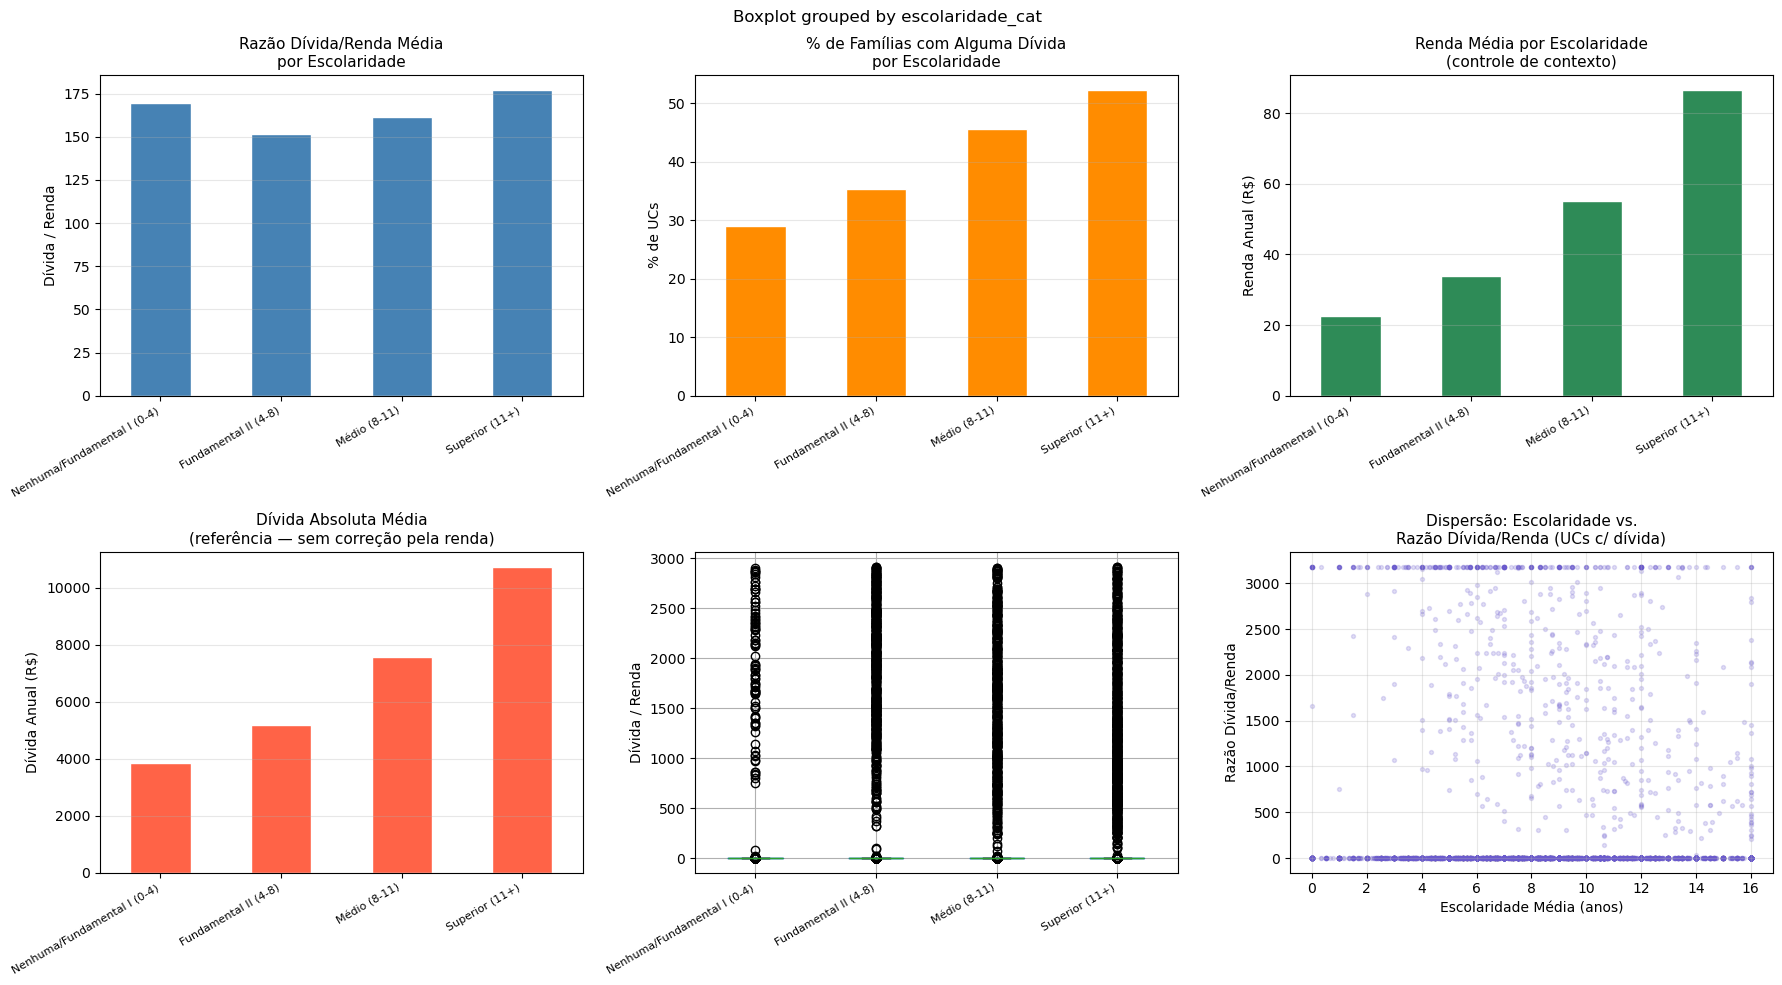

✓ Gráficos gerados.


In [9]:
# ──────────────────────────────────────────────────────────────────────────────
# 7.3  Gráficos descritivos
# ──────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Escolaridade e Endividamento Familiar — POF 2017-2018', fontsize=15, fontweight='bold')

cats = df_pandas['escolaridade_cat'].cat.categories.tolist()

# --- Painel 1: Razão dívida/renda média por escolaridade ---
ax1 = axes[0, 0]
tab_desc['razao_media'].plot(kind='bar', ax=ax1, color='steelblue', edgecolor='white')
ax1.set_title('Razão Dívida/Renda Média\npor Escolaridade', fontsize=11)
ax1.set_xlabel('')
ax1.set_ylabel('Dívida / Renda')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=30, ha='right', fontsize=8)
ax1.grid(True, alpha=0.3, axis='y')

# --- Painel 2: Proporção de famílias endividadas ---
ax2 = axes[0, 1]
pct_divida.plot(kind='bar', ax=ax2, color='darkorange', edgecolor='white')
ax2.set_title('% de Famílias com Alguma Dívida\npor Escolaridade', fontsize=11)
ax2.set_xlabel('')
ax2.set_ylabel('% de UCs')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=30, ha='right', fontsize=8)
ax2.grid(True, alpha=0.3, axis='y')

# --- Painel 3: Renda média por escolaridade ---
ax3 = axes[0, 2]
tab_desc['renda_media'].plot(kind='bar', ax=ax3, color='seagreen', edgecolor='white')
ax3.set_title('Renda Média por Escolaridade\n(controle de contexto)', fontsize=11)
ax3.set_xlabel('')
ax3.set_ylabel('Renda Anual (R$)')
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=30, ha='right', fontsize=8)
ax3.grid(True, alpha=0.3, axis='y')

# --- Painel 4: Dívida absoluta média (somente como referência) ---
ax4 = axes[1, 0]
tab_desc['divida_media'].plot(kind='bar', ax=ax4, color='tomato', edgecolor='white')
ax4.set_title('Dívida Absoluta Média\n(referência — sem correção pela renda)', fontsize=11)
ax4.set_xlabel('')
ax4.set_ylabel('Dívida Anual (R$)')
ax4.set_xticklabels(ax4.get_xticklabels(), rotation=30, ha='right', fontsize=8)
ax4.grid(True, alpha=0.3, axis='y')

# --- Painel 5: Boxplot razão dívida/renda (UCs com dívida > 0) ---
ax5 = axes[1, 1]
df_com_divida = df_pandas[df_pandas['razao_divida_renda'] > 0]
# limita outliers extremos para visualização
limite = df_com_divida['razao_divida_renda'].quantile(0.95)
df_plot = df_com_divida[df_com_divida['razao_divida_renda'] <= limite]
df_plot.boxplot(column='razao_divida_renda', by='escolaridade_cat', ax=ax5)
ax5.set_title('Distribuição Razão Dívida/Renda\n(UCs c/ dívida, até percentil 95)', fontsize=11)
ax5.set_xlabel('')
ax5.set_ylabel('Dívida / Renda')
plt.sca(ax5)
plt.xticks(rotation=30, ha='right', fontsize=8)
plt.title('')  # remove título automático do boxplot

# --- Painel 6: Dispersão escolaridade vs. razão dívida/renda ---
ax6 = axes[1, 2]
sample = df_pandas[df_pandas['razao_divida_renda'] > 0].sample(min(5000, len(df_pandas)), random_state=42)
ax6.scatter(sample['escolaridade_media'],
            sample['razao_divida_renda'].clip(upper=sample['razao_divida_renda'].quantile(0.95)),
            alpha=0.2, s=8, color='slateblue')
ax6.set_xlabel('Escolaridade Média (anos)')
ax6.set_ylabel('Razão Dívida/Renda')
ax6.set_title('Dispersão: Escolaridade vs.\nRazão Dívida/Renda (UCs c/ dívida)', fontsize=11)
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("✓ Gráficos gerados.")

## 8. Modelos de Regressão

### Justificativa metodológica

A variável `total_divida` (e a `razao_divida_renda`) tem uma distribuição
**extremamente assimétrica**: a maioria das UCs não tem dívida alguma
(total_divida = 0), e as que têm apresentam valores muito dispersos.
Isso viola os pressupostos do OLS clássico.

Um estatístico sênior usaria uma **abordagem em duas partes** (*two-part model*
ou *hurdle model*), que separa o fenômeno em duas perguntas distintas:

1. **Parte 1 — Regressão Logística**: *Qual é a probabilidade de uma UC
   TER alguma dívida?*
   - Variável dependente: `tem_divida` (0/1)
   - Captura o acesso ao crédito

2. **Parte 2 — OLS log-linear**: *Dado que a UC TEM dívida, qual é o
   montante (em log)?*
   - Variável dependente: `log(total_divida)` — normaliza a distribuição
   - Captura o volume de endividamento

Também rodamos um OLS na **razão dívida/renda** (com erro padrão robusto HC3)
como análise complementar sobre o comprometimento relativo da renda.

### Variáveis de controle
- `renda_total`: controla capacidade de pagamento
- `idade_media`: controla ciclo de vida
- `nivel_instrucao_modal`: complementa `escolaridade_media` (nível categórico)
- `n_membros`: tamanho da UC
- `sexo_chefe`: dummies de gênero do responsável
- `UF`: efeitos fixos de estado (controla desigualdades regionais)


In [10]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats
from statsmodels.stats.diagnostic import het_breuschpagan

# Prepara o dataframe de modelagem
df_model = df_pandas.copy()

# Log da dívida (apenas para UCs com dívida > 0 — usado no segundo estágio)
df_model['log_divida'] = np.where(
    df_model['total_divida'] > 0,
    np.log(df_model['total_divida']),
    np.nan
)

# Log da renda (para modelar elasticidade)
df_model['log_renda'] = np.log(df_model['renda_total'])

# Variáveis dummy
df_model['chefe_mulher'] = (df_model['sexo_chefe'] == '2').astype(int)
df_model['UF'] = df_model['UF'].astype(str)  # garante tratamento como categórica

# ──────────────────────────────────────────────────────────────────────────────
# PARTE 1: Regressão Logística
# Pergunta: A escolaridade aumenta a PROBABILIDADE de ter dívida?
# ──────────────────────────────────────────────────────────────────────────────
print("=" * 70)
print("MODELO 1 — REGRESSÃO LOGÍSTICA: P(TER DÍVIDA)")
print("Variável dependente: tem_divida (0/1)")
print("=" * 70)

formula_logit = (
    'tem_divida ~ escolaridade_media + C(nivel_instrucao_modal) '
    '+ log_renda + idade_media + n_membros + chefe_mulher + C(UF)'
)

modelo_logit = smf.logit(formula_logit, data=df_model).fit(maxiter=200, disp=False)
print(modelo_logit.summary())

# Odds-ratio para escolaridade
or_esc = np.exp(modelo_logit.params['escolaridade_media'])
ci_or  = np.exp(modelo_logit.conf_int().loc['escolaridade_media'])
print(f"\nOdds-ratio para escolaridade_media: {or_esc:.4f}  IC 95%: [{ci_or[0]:.4f}, {ci_or[1]:.4f}]")
print("  → Se OR > 1: cada ano adicional de estudo aumenta a chance de ter dívida.")
print("  → Se OR < 1: cada ano adicional de estudo reduz a chance de ter dívida.")

MODELO 1 — REGRESSÃO LOGÍSTICA: P(TER DÍVIDA)
Variável dependente: tem_divida (0/1)
                           Logit Regression Results                           
Dep. Variable:             tem_divida   No. Observations:                58033
Model:                          Logit   Df Residuals:                    57995
Method:                           MLE   Df Model:                           37
Date:                Sun, 12 Apr 2026   Pseudo R-squ.:                  0.1197
Time:                        22:19:44   Log-Likelihood:                -34331.
converged:                       True   LL-Null:                       -38998.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                        -4.2370      0.098    -43.322      0.000      -4.429   

In [11]:
# ──────────────────────────────────────────────────────────────────────────────
# PARTE 2: OLS log-linear (somente UCs com dívida > 0)
# Pergunta: Dado que a UC tem dívida, a escolaridade aumenta o VOLUME?
# ──────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("MODELO 2 — OLS LOG-LINEAR: log(DÍVIDA) | dívida > 0")
print("Variável dependente: log(total_divida)  (apenas UCs com dívida > 0)")
print("=" * 70)

df_com_divida = df_model.dropna(subset=['log_divida']).copy()

formula_ols_log = (
    'log_divida ~ escolaridade_media + C(nivel_instrucao_modal) '
    '+ log_renda + idade_media + n_membros + chefe_mulher + C(UF)'
)

modelo_ols_log = smf.ols(formula_ols_log, data=df_com_divida).fit(
    cov_type='HC3'  # erros padrão robustos à heterocedasticidade
)
print(modelo_ols_log.summary())

beta_esc = modelo_ols_log.params['escolaridade_media']
pval_esc = modelo_ols_log.pvalues['escolaridade_media']
ci_esc   = modelo_ols_log.conf_int().loc['escolaridade_media']

print(f"\nCoeficiente de escolaridade_media: {beta_esc:.4f}")
print(f"  → Interpretação (log-linear): cada ano adicional de estudo está associado")
print(f"    a uma variação de {beta_esc*100:.1f}% no montante de dívida,")
print(f"    ceteris paribus (controlando renda, idade, UF, etc.).")
print(f"  P-valor: {pval_esc:.4f}  |  IC 95%: [{ci_esc[0]:.4f}, {ci_esc[1]:.4f}]")


MODELO 2 — OLS LOG-LINEAR: log(DÍVIDA) | dívida > 0
Variável dependente: log(total_divida)  (apenas UCs com dívida > 0)
                            OLS Regression Results                            
Dep. Variable:             log_divida   R-squared:                       0.049
Model:                            OLS   Adj. R-squared:                  0.047
Method:                 Least Squares   F-statistic:                     32.04
Date:                Sun, 12 Apr 2026   Prob (F-statistic):          8.69e-219
Time:                        22:19:48   Log-Likelihood:                -64959.
No. Observations:               23070   AIC:                         1.300e+05
Df Residuals:                   23032   BIC:                         1.303e+05
Df Model:                          37                                         
Covariance Type:                  HC3                                         
                                    coef    std err          z      P>|z|      [0.025    

In [12]:
# ──────────────────────────────────────────────────────────────────────────────
# COMPLEMENTAR: OLS na razão dívida/renda (todas as UCs)
# Pergunta: A escolaridade altera o COMPROMETIMENTO relativo da renda?
# ──────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("MODELO 3 — OLS: RAZÃO DÍVIDA/RENDA (todas as UCs, erros robustos)")
print("Variável dependente: razao_divida_renda")
print("=" * 70)

# Winsoriza a razão no percentil 99 para reduzir influência de outliers extremos
p99 = df_model['razao_divida_renda'].quantile(0.99)
df_model['razao_divida_renda_w'] = df_model['razao_divida_renda'].clip(upper=p99)

formula_razao = (
    'razao_divida_renda_w ~ escolaridade_media + C(nivel_instrucao_modal) '
    '+ idade_media + n_membros + chefe_mulher + C(UF)'
    # renda NÃO entra como controle aqui — ela já está no denominador
)

modelo_razao = smf.ols(formula_razao, data=df_model).fit(cov_type='HC3')
print(modelo_razao.summary())

beta_r = modelo_razao.params['escolaridade_media']
pval_r = modelo_razao.pvalues['escolaridade_media']

print(f"\nCoeficiente de escolaridade_media: {beta_r:.6f}")
print(f"  → Cada ano adicional de estudo altera a razão dívida/renda em {beta_r:.6f} pontos.")
print(f"  P-valor: {pval_r:.4f}")
print()
if pval_r < 0.05:
    direcao = "AUMENTA" if beta_r > 0 else "REDUZ"
    print(f"  ✅ Resultado significante: maior escolaridade {direcao} o comprometimento")
    print(f"     relativo da renda com dívida (controlando por idade, UF, etc.).")
else:
    print("  ⚠️  Resultado NÃO significante para razão dívida/renda.")
    print("     Isso indicaria que, apesar de a dívida absoluta ser maior,")
    print("     o comprometimento relativo da renda pode ser semelhante entre níveis de educação.")


MODELO 3 — OLS: RAZÃO DÍVIDA/RENDA (todas as UCs, erros robustos)
Variável dependente: razao_divida_renda
                             OLS Regression Results                             
Dep. Variable:     razao_divida_renda_w   R-squared:                       0.021
Model:                              OLS   Adj. R-squared:                  0.020
Method:                   Least Squares   F-statistic:                     34.59
Date:                  Sun, 12 Apr 2026   Prob (F-statistic):          1.91e-235
Time:                          22:19:51   Log-Likelihood:            -4.5703e+05
No. Observations:                 58033   AIC:                         9.141e+05
Df Residuals:                     57996   BIC:                         9.145e+05
Df Model:                            36                                         
Covariance Type:                    HC3                                         
                                    coef    std err          z      P>|z|      [0.0

## 9. Diagnósticos dos Modelos

DIAGNÓSTICOS — MODELO 2 (OLS log-linear)

Jarque-Bera (normalidade):  estatística=10357.1, p=0.0000
  ✗ Resíduos não normais
  [NOTA] Com N grande (>30.000), JB quase sempre rejeita normalidade.
         O TLC garante que os estimadores OLS são assintoticamente válidos.
         O uso de erros robustos HC3 protege a inferência.

Breusch-Pagan (homocedasticidade): LM=1174.2, p=0.0000
  ✗ Heterocedasticidade detectada
  [NOTA] Heterocedasticidade é esperada em dados de renda/despesa.
         Erros padrão HC3 já corrigem isso — inferência válida.


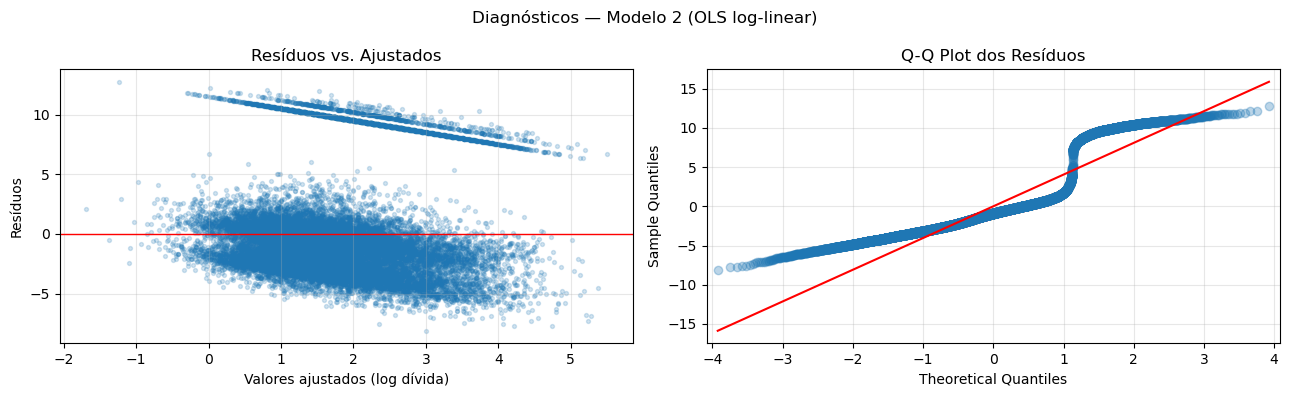


COMPARAÇÃO DE MODELOS
Métrica                             Mod.2 OLS-log        Mod.3 Razão         
---------------------------------------------------------------------------
R-quadrado                          0.0488               0.0208              
R-quad. ajustado                    0.0472               0.0202              
AIC                                 129994.5             914134.4            
N observações                       23070                58033               
β escolaridade_media                -0.0338              2.582287            
p-valor escolaridade                0.0045               0.0231              


In [13]:
from scipy.stats import jarque_bera, shapiro

print("=" * 70)
print("DIAGNÓSTICOS — MODELO 2 (OLS log-linear)")
print("=" * 70)

residuos = modelo_ols_log.resid

# Jarque-Bera (normalidade dos resíduos)
jb_stat, jb_p = jarque_bera(residuos)
print(f"\nJarque-Bera (normalidade):  estatística={jb_stat:.1f}, p={jb_p:.4f}")
print(f"  {'✗ Resíduos não normais' if jb_p < 0.05 else '✓ Resíduos aproximadamente normais'}")
print("  [NOTA] Com N grande (>30.000), JB quase sempre rejeita normalidade.")
print("         O TLC garante que os estimadores OLS são assintoticamente válidos.")
print("         O uso de erros robustos HC3 protege a inferência.")

# Breusch-Pagan (heterocedasticidade)
try:
    bp_lm, bp_p, _, _ = het_breuschpagan(residuos, modelo_ols_log.model.exog)
    print(f"\nBreusch-Pagan (homocedasticidade): LM={bp_lm:.1f}, p={bp_p:.4f}")
    print(f"  {'✗ Heterocedasticidade detectada' if bp_p < 0.05 else '✓ Variância aproximadamente constante'}")
    print("  [NOTA] Heterocedasticidade é esperada em dados de renda/despesa.")
    print("         Erros padrão HC3 já corrigem isso — inferência válida.")
except Exception as e:
    print(f"  (Teste BP não disponível: {e})")

# Gráficos diagnósticos
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Diagnósticos — Modelo 2 (OLS log-linear)', fontsize=12)

# Resíduos vs. valores ajustados
axes[0].scatter(modelo_ols_log.fittedvalues, residuos, alpha=0.2, s=8)
axes[0].axhline(0, color='red', linewidth=1)
axes[0].set_xlabel('Valores ajustados (log dívida)')
axes[0].set_ylabel('Resíduos')
axes[0].set_title('Resíduos vs. Ajustados')
axes[0].grid(True, alpha=0.3)

# QQ-plot dos resíduos
sm.qqplot(residuos, line='s', ax=axes[1], alpha=0.3)
axes[1].set_title('Q-Q Plot dos Resíduos')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Comparação de modelos
print("\n" + "=" * 70)
print("COMPARAÇÃO DE MODELOS")
print("=" * 70)
print(f"{'Métrica':<35} {'Mod.2 OLS-log':<20} {'Mod.3 Razão':<20}")
print("-" * 75)
print(f"{'R-quadrado':<35} {modelo_ols_log.rsquared:<20.4f} {modelo_razao.rsquared:<20.4f}")
print(f"{'R-quad. ajustado':<35} {modelo_ols_log.rsquared_adj:<20.4f} {modelo_razao.rsquared_adj:<20.4f}")
print(f"{'AIC':<35} {modelo_ols_log.aic:<20.1f} {modelo_razao.aic:<20.1f}")
print(f"{'N observações':<35} {int(modelo_ols_log.nobs):<20} {int(modelo_razao.nobs):<20}")
print(f"{'β escolaridade_media':<35} {modelo_ols_log.params['escolaridade_media']:<20.4f} {modelo_razao.params['escolaridade_media']:<20.6f}")
print(f"{'p-valor escolaridade':<35} {modelo_ols_log.pvalues['escolaridade_media']:<20.4f} {modelo_razao.pvalues['escolaridade_media']:<20.4f}")

## Teste ANOVA e sumário final

In [14]:
from scipy.stats import f_oneway, kruskal

print("=" * 70)
print("TESTES DE DIFERENÇA ENTRE GRUPOS DE ESCOLARIDADE")
print("=" * 70)

grupos_razao = [
    df_pandas[df_pandas['escolaridade_cat'] == cat]['razao_divida_renda'].dropna().values
    for cat in df_pandas['escolaridade_cat'].cat.categories
]

# ANOVA paramétrica
f_stat, p_anova = f_oneway(*grupos_razao)
print(f"\nANOVA (razão dívida/renda): F={f_stat:.2f}, p={p_anova:.2e}")
print(f"  {'✓ Diferenças significantes entre grupos' if p_anova < 0.05 else '✗ Sem diferenças significantes'}")

# Kruskal-Wallis (não-paramétrico — mais robusto para dados assimétricos)
h_stat, p_kw = kruskal(*grupos_razao)
print(f"\nKruskal-Wallis (razão dívida/renda): H={h_stat:.2f}, p={p_kw:.2e}")
print(f"  {'✓ Diferenças significantes entre grupos' if p_kw < 0.05 else '✗ Sem diferenças significantes'}")
print("  [NOTA] Kruskal-Wallis é preferível para dados com muitos zeros e assimetria.")

print("\n" + "=" * 70)
print("SUMÁRIO EXECUTIVO")
print("=" * 70)
print(f"""
Dataset: {len(df_pandas):,} UCs (famílias) da POF 2017-2018
UCs com alguma dívida: {df_pandas['tem_divida'].sum():,} ({df_pandas['tem_divida'].mean()*100:.1f}%)

MODELO 1 — Logístico (P(ter dívida)):
  Odds-ratio escolaridade: {np.exp(modelo_logit.params['escolaridade_media']):.4f}
  p-valor: {modelo_logit.pvalues['escolaridade_media']:.4f}

MODELO 2 — OLS log-linear (log dívida | dívida > 0):
  β escolaridade: {modelo_ols_log.params['escolaridade_media']:.4f}
  → Cada ano adicional de estudo associado a {modelo_ols_log.params['escolaridade_media']*100:.1f}% no montante de dívida
  p-valor: {modelo_ols_log.pvalues['escolaridade_media']:.4f}

MODELO 3 — OLS razão dívida/renda:
  β escolaridade: {modelo_razao.params['escolaridade_media']:.6f}
  p-valor: {modelo_razao.pvalues['escolaridade_media']:.4f}

CONCLUSÃO PRELIMINAR:
  Compare os três modelos para uma narrativa completa:
  - Se o logístico for sig. positivo: escolaridade aumenta ACESSO ao crédito
  - Se o OLS-log for sig. positivo: dado o acesso, escolaridade também aumenta VOLUME
  - Se a razão for sig. positiva: o comprometimento relativo da renda também é maior
  - Se a razão NÃO for sig.: a dívida cresce proporcionalmente à renda (sem sobreendividamento)
""")

TESTES DE DIFERENÇA ENTRE GRUPOS DE ESCOLARIDADE

ANOVA (razão dívida/renda): F=1.85, p=1.37e-01
  ✗ Sem diferenças significantes

Kruskal-Wallis (razão dívida/renda): H=997.93, p=5.06e-216
  ✓ Diferenças significantes entre grupos
  [NOTA] Kruskal-Wallis é preferível para dados com muitos zeros e assimetria.

SUMÁRIO EXECUTIVO

Dataset: 58,033 UCs (famílias) da POF 2017-2018
UCs com alguma dívida: 23,070 (39.8%)

MODELO 1 — Logístico (P(ter dívida)):
  Odds-ratio escolaridade: 1.0224
  p-valor: 0.0000

MODELO 2 — OLS log-linear (log dívida | dívida > 0):
  β escolaridade: -0.0338
  → Cada ano adicional de estudo associado a -3.4% no montante de dívida
  p-valor: 0.0045

MODELO 3 — OLS razão dívida/renda:
  β escolaridade: 2.582287
  p-valor: 0.0231

CONCLUSÃO PRELIMINAR:
  Compare os três modelos para uma narrativa completa:
  - Se o logístico for sig. positivo: escolaridade aumenta ACESSO ao crédito
  - Se o OLS-log for sig. positivo: dado o acesso, escolaridade também aumenta VOLUME